In [2]:


import sys

import pandas as pd
from sqlalchemy import bindparam
from sqlalchemy import create_engine
from sqlalchemy import text

from nhs_waiting_lists.utils.proj_paths import find_project_root
from pathlib import Path
from nhs_waiting_lists import (
    __app_name__,
)
from nhs_waiting_lists.constants import proj_db_path
from nhs_waiting_lists.utils.xdg import XDGBasedir
project_root = Path(XDGBasedir.get_data_dir(__app_name__))
from nhs_waiting_lists.constants import DB_FILE

DB_PATH = project_root / proj_db_path / DB_FILE
DATA_DIR = "./data"

engine = create_engine(f"sqlite:///{DB_PATH}", echo=True)

In [3]:
PROVIDER_CODES = ['RAJ']
TREATMENT_CODES = ('C_320',)

In [4]:

from sqlalchemy import text

query = text("""
             SELECT *
             from all_rtt
             WHERE provider_org_code IN :provider_codes
             AND treatment_function_code IN :treatment_codes; \
             """).bindparams(
    bindparam('provider_codes', expanding=True),
    bindparam('treatment_codes', expanding=True)
)

df = pd.read_sql(
    query, engine, params={  # type: ignore[arg-type]
        'provider_codes': PROVIDER_CODES,
        'treatment_codes': TREATMENT_CODES,
    }
)

df

2025-11-19 11:51:14,850 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-11-19 11:51:14,850 INFO sqlalchemy.engine.Engine 
             SELECT *
             from all_rtt
             WHERE provider_org_code IN (?)
             AND treatment_function_code IN (?);              
2025-11-19 11:51:14,851 INFO sqlalchemy.engine.Engine [generated in 0.00177s] ('RAJ', 'C_320')
2025-11-19 11:51:14,852 INFO sqlalchemy.engine.Engine ROLLBACK


OperationalError: (sqlite3.OperationalError) no such table: all_rtt
[SQL: 
             SELECT *
             from all_rtt
             WHERE provider_org_code IN (?)
             AND treatment_function_code IN (?);              ]
[parameters: ('RAJ', 'C_320')]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [4]:
df.columns


Index(['period', 'provider_org_code', 'rtt_part_type',
       'treatment_function_code', 'gt_00_to_01_weeks', 'gt_01_to_02_weeks',
       'gt_02_to_03_weeks', 'gt_03_to_04_weeks', 'gt_04_to_05_weeks',
       'gt_05_to_06_weeks',
       ...
       'gt_98_to_99_weeks', 'gt_99_to_100_weeks', 'gt_100_to_101_weeks',
       'gt_101_to_102_weeks', 'gt_102_to_103_weeks', 'gt_103_to_104_weeks',
       'gt_104_weeks', 'patients_with_unknown_clock_start_date', 'total',
       'total_all'],
      dtype='object', length=112)

Text(0, 0.5, 'Cumulative share still waiting')

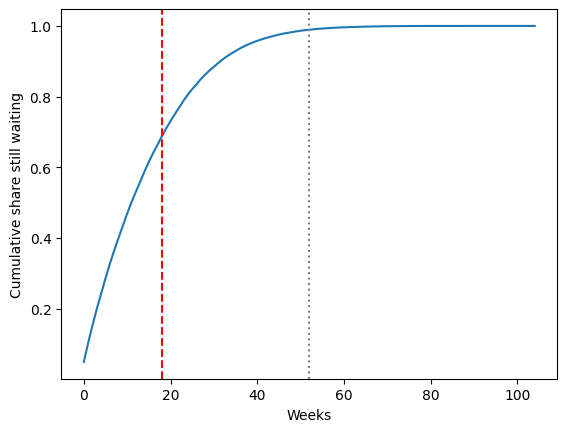

In [5]:
import pandas as pd, matplotlib.pyplot as plt
cols = [c for c in df.columns if c.startswith('gt_') and 'weeks' in c]
waits = df.loc[df['rtt_part_type']=='Part_2', cols].sum()
cdf = waits.cumsum()/waits.sum()
plt.plot(range(len(cdf)), cdf)
plt.axvline(18, color='r', ls='--'); plt.axvline(52, color='gray', ls=':')
plt.xlabel('Weeks'); plt.ylabel('Cumulative share still waiting')

In [6]:
from nhs_waiting_lists.constants import wait_ranges

# Melt to long form for one month and one RTT part
subset = df[(df['period'] == '2024-06') & (df['rtt_part_type'] == 'Part_2')]
wait_profile = subset.melt(
    id_vars=['provider_org_code', 'treatment_function_code'],
    value_vars=wait_ranges,
    var_name='weeks', value_name='count'
)

<Axes: >

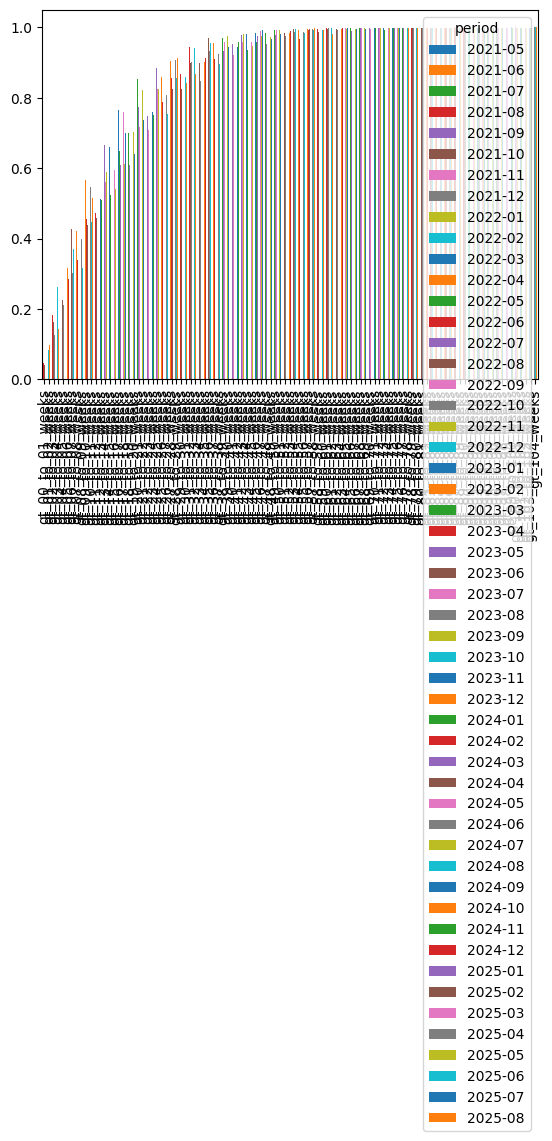

In [7]:
# optional: convert 'gt_18_to_19_weeks' → numeric midpoint for plotting
# cumulative proportion by month
profile = df.groupby('period')[wait_ranges].sum()
profile = profile.cumsum(axis=1).div(profile.sum(axis=1), axis=0)
profile.T.plot(kind='bar')   # 0–104 weeks on x, % waited on y

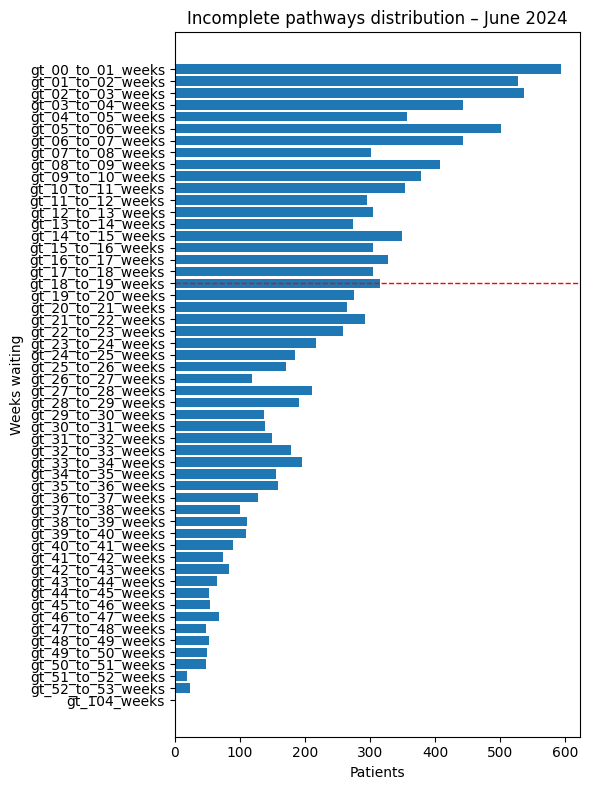

In [8]:
import matplotlib.pyplot as plt

week_cols = [f"gt_{n:02}_to_{n+1:02}_weeks" for n in range(52)] + ["gt_52_to_53_weeks","gt_104_weeks"]
subset = df[(df['period']=='2024-06') & (df['rtt_part_type']=='Part_2')]
counts = subset[week_cols].sum().reset_index()
counts.columns = ['week_band','patients']

fig, ax = plt.subplots(figsize=(6,8))
ax.barh(counts['week_band'], counts['patients'])
ax.axhline(y='gt_18_to_19_weeks', color='red', ls='--', lw=1)
ax.set_xlabel('Patients')
ax.set_ylabel('Weeks waiting')
ax.set_title('Incomplete pathways distribution – June 2024')
plt.gca().invert_yaxis()  # so 0–1 weeks is at top
plt.tight_layout()
plt.show()


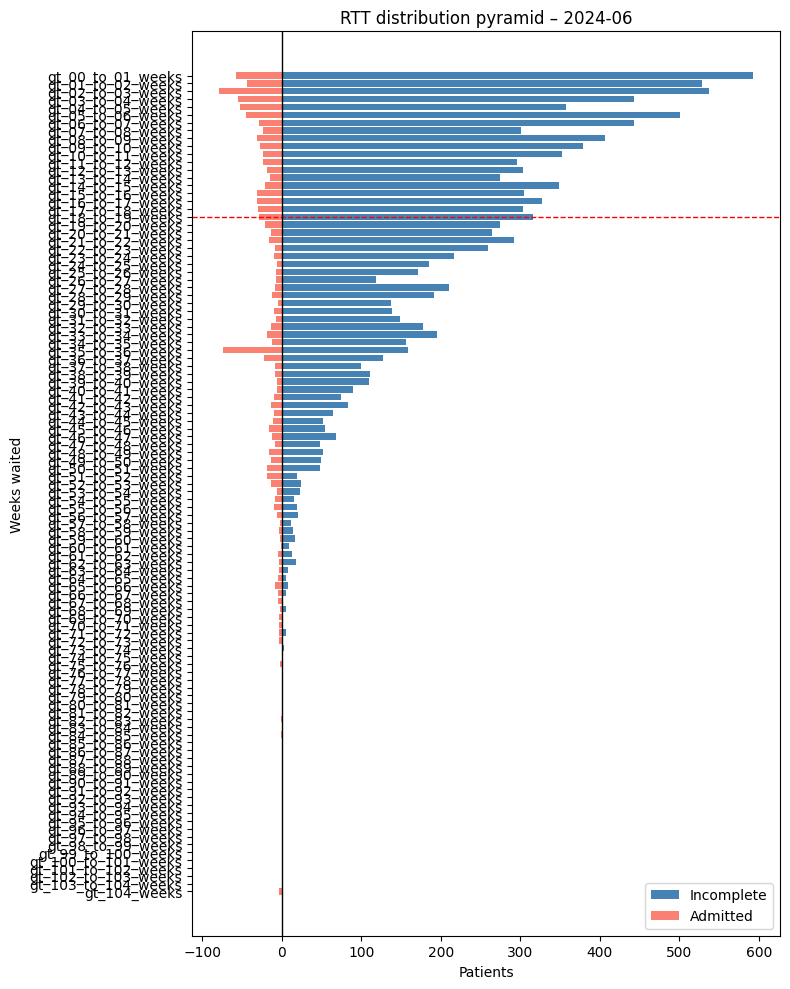

In [9]:
from nhs_waiting_lists.constants import wait_ranges_lt_18, wait_ranges_gte_18
import numpy as np

period = "2024-06"
weeks = wait_ranges_lt_18 + wait_ranges_gte_18
part_a = df[(df['period']==period) & (df['rtt_part_type']=='Part_2')][weeks].sum()
part_b = df[(df['period']==period) & (df['rtt_part_type']=='Part_1B')][weeks].sum()

fig, ax = plt.subplots(figsize=(8,10))
ax.barh(weeks, part_a, color='steelblue', label='Incomplete')
ax.barh(weeks, -part_b, color='salmon', label='Admitted')
ax.axhline(y='gt_18_to_19_weeks', color='red', ls='--', lw=1)
ax.set_xlabel('Patients')
ax.set_ylabel('Weeks waited')
ax.set_title(f'RTT distribution pyramid – {period}')
ax.legend()
ax.axvline(0, color='black', lw=1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
